# Load Libraries

In [3]:
from functions.project_config import load_user_paths
USER_PATHS = load_user_paths()


%load_ext autoreload
%autoreload 2



# Basic libraries
import pandas as pd
import numpy as np
import sys



# Scipy
import scipy
from scipy import signal
from scipy.linalg import solve
from scipy import constants
from scipy.interpolate import interp1d
from scipy.fft import fft, fftfreq

# Locate files
import os
from pathlib import Path
from glob import glob

# Plots
from matplotlib import pyplot as plt

#Important!! Make sure your current directory is the MHDTurbPy folder!
os.chdir(USER_PATHS['repo_root'])


# Make sure to use the local spedas
sys.path.insert(0, os.path.join(os.getcwd(), 'pyspedas'))
import pyspedas
from pyspedas.utilities import time_string
from pytplot import get_data
from joblib import Parallel, delayed

""" Import manual functions """

sys.path.insert(1, os.path.join(os.getcwd(), 'functions'))
import calc_diagnostics as calc
import TurbPy as turb
import general_functions as func
import Figures as figs

from   SEA import SEA
import three_D_funcs as threeD
import download_data as download

sys.path.insert(1, os.path.join(os.getcwd(), 'functions/3d_anis_analysis_toolboox'))
import collect_wave_coeffs 
import data_analysis 



os.environ["CDF_LIB"] = "/Applications/cdf/cdf/lib"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ImportError: cannot import name 'LoadTimeSeriesACE' from 'ACE' (/Users/turbulator/work/MHDTurbPy/functions/downloading_helpers/ACE.py)

In [15]:
import numpy as np
import pandas as pd
import traceback

def mre_inspect_soar_merged(
    t0: str,
    t1: str,
    *,
    fs: int = 256,
    frame: str = "rtn",   # "rtn" or "srf"
):
    """
    Minimal MRE to:
      - fetch SOAR merged SolO product
      - print CDF variables
      - show what YOUR loader returns
    """
    import cdflib
    from sunpy.net import Fido
    import sunpy.net.attrs as a
    import sunpy_soar  # noqa: F401

    t0_dt = pd.to_datetime(t0)
    t1_dt = pd.to_datetime(t1)

    product = f"multi-mag-rpw-scm-merged-{frame}-{fs}"

    print("\n===============================")
    print("SOAR PRODUCT:", product)
    print("TIME RANGE:", t0_dt, "->", t1_dt)
    print("===============================\n")

    qr = Fido.search(a.Time(t0_dt, t1_dt), a.soar.Product(product))
    print("Search results:", len(qr))
    if len(qr) == 0:
        print("No files found.")
        return None

    files = Fido.fetch(qr)
    if files is None or len(files) == 0:
        print("Fetch returned no files.")
        return None

    print("Fetched files:", len(files))
    fp0 = str(files[0])
    print("Using FIRST file:", fp0)

    # ----------------------------
    # 1) Inspect full CDF contents
    # ----------------------------
    try:
        cdf = cdflib.CDF(fp0)
        info = cdf.cdf_info()

        zvars = list(info.zVariables) if hasattr(info, "zVariables") else list(info.get("zVariables", []))
        rvars = list(info.rVariables) if hasattr(info, "rVariables") else list(info.get("rVariables", []))

        print("\n--- CDF INFO ---")
        print("zVariables (N={}):".format(len(zvars)))
        for v in zvars:
            print("  ", v)

        if len(rvars) > 0:
            print("\nrVariables (N={}):".format(len(rvars)))
            for v in rvars:
                print("  ", v)

        # Print a few candidate variables details
        candidates = [
            "Epoch",
            "B_RTN", "B_SRF",
            "QUALITY_FLAG",
            "QUALITY_BITMASK_MAG",
            "QUALITY_BITMASK_SCM",
            "MERGED_BITMASK",
            "MERGED_LABEL",
            "SAMPLING_RATE",
        ]

        print("\n--- CANDIDATE VARIABLE SUMMARY ---")
        for v in candidates:
            if v not in zvars:
                continue
            try:
                arr = cdf.varget(v)
                shape = None if arr is None else np.asarray(arr).shape
                dtype = None if arr is None else np.asarray(arr).dtype
                print(f"{v:20s} | shape={shape} dtype={dtype}")
            except Exception:
                print(f"{v:20s} | ERROR reading")
                traceback.print_exc()

    except Exception as e:
        print("Failed reading CDF:", e)
        traceback.print_exc()
        return None

    # ----------------------------
    # 2) Reproduce YOUR loader logic
    # ----------------------------
    print("\n--- WHAT YOUR LOADER WOULD RETURN ---")

    if frame == "rtn":
        want_var = "B_RTN"
        cols = ["Br", "Bt", "Bn"]
    else:
        want_var = "B_SRF"
        cols = ["Bx", "By", "Bz"]

    # fallback if requested not available
    if want_var not in zvars:
        if "B_RTN" in zvars:
            want_var = "B_RTN"
            cols = ["Br", "Bt", "Bn"]
        elif "B_SRF" in zvars:
            want_var = "B_SRF"
            cols = ["Bx", "By", "Bz"]
        else:
            print("Neither B_RTN nor B_SRF found. Loader would return empty DF.")
            return None

    epoch_tt2000 = cdf.varget("Epoch")
    B = cdf.varget(want_var)

    epoch_dt = pd.to_datetime(cdflib.cdfepoch.to_datetime(epoch_tt2000)).tz_localize(None)
    df = pd.DataFrame(np.asarray(B), index=epoch_dt, columns=cols)

    df = df.loc[(df.index >= t0_dt) & (df.index <= t1_dt)]
    print("Returned DF columns:", df.columns.tolist())
    print("Returned DF shape:", df.shape)
    print("Returned DF time span:", df.index.min(), "->", df.index.max())

    # show head/tail
    print("\nHEAD:")
    print(df.head(3))
    print("\nTAIL:")
    print(df.tail(3))

    return df


# ===========================
# RUN THIS (edit times only)
# ===========================
out = mre_inspect_soar_merged(
    # t0="2024-10-10 00:04:12",
    # t1="2024-10-10 00:14:12",

    t0  = "2024-10-10 00:00",
    t1  =  "2024-10-10 06:00",
    fs=256,
    frame="rtn",
)



SOAR PRODUCT: multi-mag-rpw-scm-merged-rtn-256
TIME RANGE: 2024-10-10 00:00:00 -> 2024-10-10 06:00:00

Search results: 1


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Fetched files: 1
Using FIRST file: /Users/turbulator/sunpy/data/solo_L3_multi-mag-rpw-scm-merged-rtn-256_20241010_V01.cdf

--- CDF INFO ---
zVariables (N=11):
   Epoch
   B_RTN
   QUALITY_BITMASK
   MERGED_BITMASK
   MERGED_LABEL
   MAG_LABEL_RTN
   QUALITY_FLAG
   QUALITY_BITMASK_MAG
   QUALITY_BITMASK_SCM
   SAMPLING_RATE
   CARTESIAN_REPRESENTATION

--- CANDIDATE VARIABLE SUMMARY ---
Epoch                | shape=(13991936,) dtype=int64
B_RTN                | shape=(13991936, 3) dtype=float32
QUALITY_FLAG         | shape=(13991936,) dtype=uint8
QUALITY_BITMASK_MAG  | shape=(13991936,) dtype=uint16
QUALITY_BITMASK_SCM  | shape=(13991936,) dtype=uint16
MERGED_BITMASK       | shape=(13991936,) dtype=uint8
MERGED_LABEL         | shape=(256,) dtype=<U47
SAMPLING_RATE        | shape=(13991936,) dtype=float32

--- WHAT YOUR LOADER WOULD RETURN ---
Returned DF columns: ['Br', 'Bt', 'Bn']
Returned DF shape: (1458176, 3)
Returned DF time span: 2024-10-10 00:04:11.040509056 -> 2024-10-10 05:59:

Estimated fs = 333.333333 Hz
Quiet-window threshold (mean PSD in 0.5–1 Hz) = 1.492e-07 nT^2/Hz
Quiet windows kept = 267


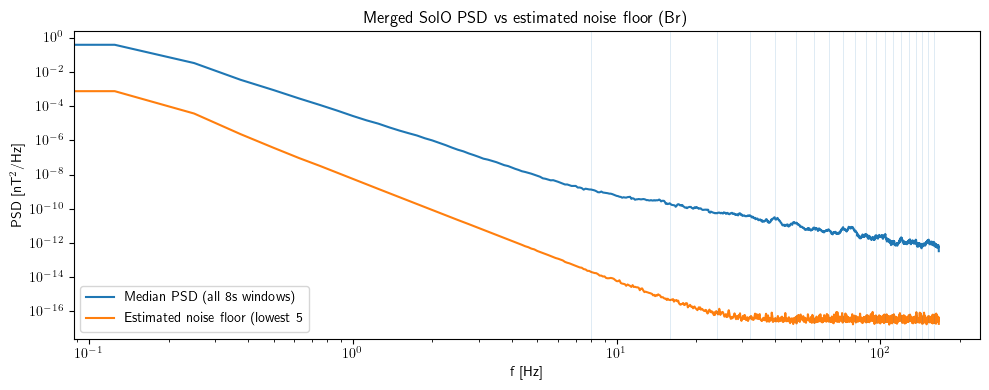

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram, welch

def estimate_noise_floor_psd(
    x: np.ndarray,
    fs: float,
    *,
    win_seconds: float = 8.0,
    overlap: float = 0.5,
    quiet_band_hz: tuple[float, float] = (0.5, 1.0),
    quiet_quantile: float = 0.05,
):
    """
    Estimate noise floor PSD by:
      1) computing windowed PSDs via spectrogram(mode='psd')
      2) selecting the lowest-activity windows based on mean power in quiet_band_hz
      3) returning the median PSD across those quiet windows

    Returns:
      f, P_med_all, P_noise_est, quiet_mask, quiet_threshold
    """
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size < 4096:
        raise ValueError("Signal too short / too many NaNs after cleaning.")

    nperseg = int(round(fs * win_seconds))
    nperseg = max(256, min(nperseg, x.size))
    noverlap = int(round(overlap * nperseg))
    noverlap = max(0, min(noverlap, nperseg - 1))

    f, t, Pxx = spectrogram(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",
        mode="psd",
    )  # Pxx shape = (nf, nt)

    f0, f1 = quiet_band_hz
    band = (f >= f0) & (f <= f1)
    if band.sum() < 3:
        raise ValueError("quiet_band_hz too narrow for your frequency resolution.")

    band_power = np.nanmean(Pxx[band, :], axis=0)   # one value per time-window
    thr = np.nanquantile(band_power, quiet_quantile)
    quiet_mask = band_power <= thr

    P_med_all = np.nanmedian(Pxx, axis=1)                 # typical spectrum
    P_noise_est = np.nanmedian(Pxx[:, quiet_mask], axis=1) # noise floor estimate

    return f, P_med_all, P_noise_est, quiet_mask, thr


# ============================================================
# APPLY TO YOUR DATAFRAME (merged product)
# ============================================================
Bdf = fin["Mag"]["B_resampled"]  # must be uniform cadence

# infer fs from index
t_ns = Bdf.index.view("int64")
dt = np.diff(t_ns).astype(np.float64) * 1e-9
fs = 1.0 / np.nanmedian(dt)
print(f"Estimated fs = {fs:.6f} Hz")

# choose component (Br)
x = Bdf["Br"].to_numpy(dtype=float)

f, P_med, P_noise, quiet_mask, thr = estimate_noise_floor_psd(
    x,
    fs,
    win_seconds=8.0,
    overlap=0.5,
    quiet_band_hz=(0.5, 1.0),
    quiet_quantile=0.05,  # lowest 5% windows
)

print(f"Quiet-window threshold (mean PSD in 0.5–1 Hz) = {thr:.3e} nT^2/Hz")
print(f"Quiet windows kept = {quiet_mask.sum()}")

# ============================================================
# PLOT: typical PSD vs estimated noise floor
# ============================================================
plt.figure(figsize=(10, 4))
plt.loglog(f, P_med, label="Median PSD (all 8s windows)")
plt.loglog(f, P_noise, label="Estimated noise floor (lowest 5% windows)")

# mark known clock harmonics (optional)
for k in range(1, 40):
    fk = 8.0 * k
    if fk < 0.5 * fs:
        plt.axvline(fk, linewidth=0.5, alpha=0.2)

plt.xlabel("f [Hz]")
plt.ylabel("PSD [nT$^2$/Hz]")
plt.title("Merged SolO PSD vs estimated noise floor (Br)")
plt.legend()
plt.tight_layout()
plt.show()


# The distance data are a bit problematic. Download and save them

In [27]:
from functions.project_config import load_user_paths
USER_PATHS = load_user_paths()

cdf_lib_path = USER_PATHS['cdf_lib_path']

sys.path.insert(1, os.path.join(os.getcwd(), 'functions/downloading_helpers'))
#from  PSP import  LoadTimeSeriesPSP, download_ephemeris_PSP
from  SOLO import *


solo_dist_path = Path(USER_PATHS.get('solo_dist_path', Path(USER_PATHS['save_destination']).joinpath('SOLO', 'solo_dist.pkl')))
save_path  = str(solo_dist_path.parent)
fname      = solo_dist_path.name
t0, t1     ='2020-06-01', '2025-01-01'
dfmag      =  download_ephem_SOLO(t0, t1, cdf_lib_path)

dfmag      = dfmag.resample('5min').asfreq().interpolate(method='linear')
dist_df    = pd.DataFrame(dfmag['Dist_au'])
func.savepickle(dist_df, save_path, fname)

NameError: name 'download_ephem_SOLO' is not defined

# Download data


In [2]:
pwd

'/Users/turbulator/work/MHDTurbPy'

In [17]:
from functions.project_config import load_user_paths
USER_PATHS = load_user_paths()

"""
mre_run_solo.py

Minimal-but-complete MRE to run the SOLO pipeline.

RUN FROM REPO ROOT (the directory that contains: pyspedas/, functions/, download_data.py)
"""

from __future__ import annotations

import os
from pathlib import Path
from joblib import Parallel, delayed

import download_data as download


# ---------------------------------------------------------------------
# CDFlib path (needed for SOLO distance download via CDAS)
# ---------------------------------------------------------------------
cdf_lib_path = USER_PATHS['cdf_lib_path']


# ---------------------------------------------------------------------
# Credentials (None is fine for SOLO in most cases)
# ---------------------------------------------------------------------
credentials = None


# ---------------------------------------------------------------------
# Settings (organized by topic, then flattened into one dict)
# ---------------------------------------------------------------------
Paths = {
    
    "Data_path"         : USER_PATHS["Data_path"],
    "save_destination"  : USER_PATHS["save_destination"],
    "SOLO_dist_path"    : USER_PATHS.get("solo_dist_path", str(Path(USER_PATHS["save_destination"]).joinpath("SOLO", "solo_dist.pkl"))),
}

Mission = { 
    "sc"             : "SOLO",
    "in_rtn"         : 1,
    "use_local_data" : False,
}

Intervals = {
    "start_date": "2024-10-10 00:00",
    "end_date": "2024-10-10 06:00",
    "multiple_intervals": False,   # False -> single interval, True -> use Step/duration below
    "duration": "4H",
    "Step": "210min",
    "addit_time_around": 1,        # hours padding in LoadTimeSeriesSOLO
}

Sampling = {
    "part_resol": 500,
    "MAG_resol": 1,
    "upsample_low_freq_ts": False,
}

QualityControl = {
    "overwrite_files"   :  1,
    "must_have_qtn": False,
    "Max_par_missing": 30,
    "gap_time_threshold": 5,
    "use_hampel": False,
    "hampel_params": {"w": 200, "std": 3},
}

Output = {
    
    "save_all": True,
    "cut_in_small_windows": {
        "flag": False,
        "njobs": 1,
        "Step": "5s",
        "duration": "30s",
    },
}

Diagnostics = {
    "estimate_derived_param": True,
    "rol_window": "60min",

    "PSDs": {"flag": False},
    "struc_funcs": {"flag": False},

    "npt_struc_funcs": {
        "flag": False,
        "five_points_sfunc": True,
        "return_Bmod": True,
        "dt_step": 0.25,
        "est_sfuncs": False,
        "max_qorder": 8,
    },

    "estimate_psd_b": True,
    "estimate_psd_v": True,
    "est_PSD_components": True,
    "smooth_psd": False,
}

Gaps = {
    "Big_Gaps": {
        "E_big_gaps": 10,
        "SC_pot_big_gaps": 10,
        "Mag_big_gaps": 500,
        "Par_big_gaps": 500,
        "QTN_big_gaps": 10,
    }
}

SOLO = {
    "SOLO_use_merged_MAG": True,   # set False to use SPEDAS L2 MAG
    "SOLO_merged_fs": 256,         # 256 or 4096
}

# ---- Unified MAG noise removal (works for SOLO merged MAG and PSP SCAM)
# This is the preferred key; legacy Mag_SCAM_PSP["noise_flag"] still works.
MAG_NOISE = {
    "Mag_SCM": {
        "noise_flag": False,
        "noise_removal": {
            "freq_min": 8.0,

            "stft_nperseg": 2048,
            "stft_overlap": 0.5,

            "percentile_q": 99.5,
            "kernel": 301,
            "thresh_db": 3.0,
            "merge_hz": 0.20,
            "max_lines": 2000,

            "track_half_width_hz": 5.0,
            "remove_half_width_hz": 1.5,
            "atten_db": 100.0,

            "fallback_top_k": 120,
            "whiten_exp": 0.0,
        },
    }
}







# ---- final settings dict (what pipeline consumes)
settings = {
    **Paths,
    **Mission,
    **Intervals,
    **Sampling,
    **QualityControl,
    **Output,
    **Diagnostics,
    **SOLO,
    **MAG_NOISE,
    "Big_Gaps": Gaps["Big_Gaps"],
}


# ---------------------------------------------------------------------
# What variables to download (None -> defaults inside SOLO.py)
# ---------------------------------------------------------------------
vars_2_downnload = {
    "mag": None,
    "swa": None,
    "rpw": None,
    "ephem": None,
}


# ---------------------------------------------------------------------
# Interval generation
# ---------------------------------------------------------------------
generated_interval_list = download.generate_intervals(
    settings["start_date"],
    settings["end_date"],
    settings["multiple_intervals"],
    data_path=settings["Data_path"],
    settings=settings,
)


# ---------------------------------------------------------------------
# Run download for each interval
# ---------------------------------------------------------------------
os.chdir(settings["Data_path"])

save_path = Path(settings["save_destination"]).joinpath(settings["sc"])
save_path.mkdir(parents=True, exist_ok=True)

Parallel(n_jobs=1)(
    delayed(download.download_files)(
        jj,
        generated_interval_list,
        settings,
        vars_2_downnload,
        cdf_lib_path,
        credentials,
        save_path,
    )
    for jj in range(len(generated_interval_list))
)


20-Jan-26 09:01:48: Generating only one interval based on the provided start and end times.
20-Jan-26 09:01:48: Start Time: 2024-10-10 00:00:00
20-Jan-26 09:01:48: End Time: 2024-10-10 06:00:00
20-Jan-26 09:01:48: Considering a single interval spanning: 2024-10-10 00:00:00 to 2024-10-10 06:00:00
20-Jan-26 09:01:48: Overwriting folder /Users/turbulator/work/MHDTurbPy/examples/SOLO/2024-10-10_00-00-00_2024-10-10_06-00-00_sc_0


Working on SOLO data


20-Jan-26 09:01:49: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/rpw/science/l3/bia-density-10-seconds/2024/
20-Jan-26 09:01:49: Remote index not found: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/rpw/science/l3/bia-density-10-seconds/2024/
20-Jan-26 09:01:51: Skipping remote index: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/rpw/science/l3/bia-density-10-seconds/2024/ (previous attempt failed)
20-Jan-26 09:01:51: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/swa/science/l2/pas-grnd-mom/2024/
20-Jan-26 09:01:51: File is current: solar_orbiter_data/swa/science/l2/pas-grnd-mom/2024/solo_l2_swa-pas-grnd-mom_20241009_v02.cdf
20-Jan-26 09:01:52: File is current: solar_orbiter_data/swa/science/l2/pas-grnd-mom/2024/solo_l2_swa-pas-grnd-mom_20241010_v02.cdf
Traceback (most recent call last):
  File "/Users/turbulator/miniforge3/envs/mhdturbpy/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3699, in ru

# Load data

In [3]:
#  User defined parameters
sc          = 'SOLO'
which_int   = 0
#load_path = USER_PATHS['save_destination']
          
load_path = USER_PATHS['save_destination']

# Locate the downloaded files
finnames      = func.load_files(load_path, 'final.pkl')
gennames      = func.load_files(load_path, 'general.pkl')
signames      = func.load_files(load_path, 'sig_c_sig_r.pkl')
maggaps       = func.load_files(load_path, 'mag_gaps.pkl')
qtngaps       = func.load_files(load_path, 'qtn_gaps.pkl')
pargaps       = func.load_files(load_path, 'par_gaps.pkl')
sc_pot        = func.load_files(load_path, 'sc_pot_gaps.pkl')


#Load the filed
fin         = pd.read_pickle(finnames[which_int])
gen         = pd.read_pickle(gennames[which_int])
sig         = pd.read_pickle(signames[which_int])
mag_gaps    = pd.read_pickle(maggaps[which_int])
qtn_gaps    = pd.read_pickle(qtngaps[which_int])
par_gaps    = pd.read_pickle(pargaps[which_int])
sc_pot_gaps = pd.read_pickle(sc_pot[which_int])

finnames[which_int]

/Users/turbulator/work/MHDTurbPy/examples/SOLO/*/final.pkl
/Users/turbulator/work/MHDTurbPy/examples/SOLO/*/general.pkl
/Users/turbulator/work/MHDTurbPy/examples/SOLO/*/sig_c_sig_r.pkl
/Users/turbulator/work/MHDTurbPy/examples/SOLO/*/mag_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/SOLO/*/qtn_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/SOLO/*/par_gaps.pkl
/Users/turbulator/work/MHDTurbPy/examples/SOLO/*/sc_pot_gaps.pkl


np.str_('/Users/turbulator/work/MHDTurbPy/examples/SOLO/2024-10-10_00-00-00_2024-10-10_06-00-00_sc_0/final.pkl')

# Visualize data 

In [ ]:
# user defined parameters
w                 = '10s'
sc                = 'SOLO'
label_size        = 'large'
legend_font_size  = 'x-large'

n_subplots        = 7                                     # number os subplots
my_dir            = USER_PATHS["save_destination"] #
format_2_return   = "%Y_%m_%d"                            # Format to save figures


figs.visualize_downloaded_intervals(
                                  sc                         ,
                                  fin['Par']['V_resampled'].rolling(w, center=True).mean() ,
                                  fin['Mag']['B_resampled'].rolling(w, center=True).mean() ,
                                  sig.rolling(w, center=True).mean()   ,
                                  my_dir,
                                  format_2_return  = "%Y_%m_%d",  #
                                  size             = label_size,
                                  font_size        = legend_font_size, 
                                  numb_subplots    = n_subplots
                                 )



19-Jan-26 10:23:48: /Users/turbulator/work/MHDTurbPy/functions/Figures.py:998: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()



# Estimate Power Spectral Density (PSD) of the magnetic field.
 - When using high resolution data, 'smoothing_function' is going to be slow!

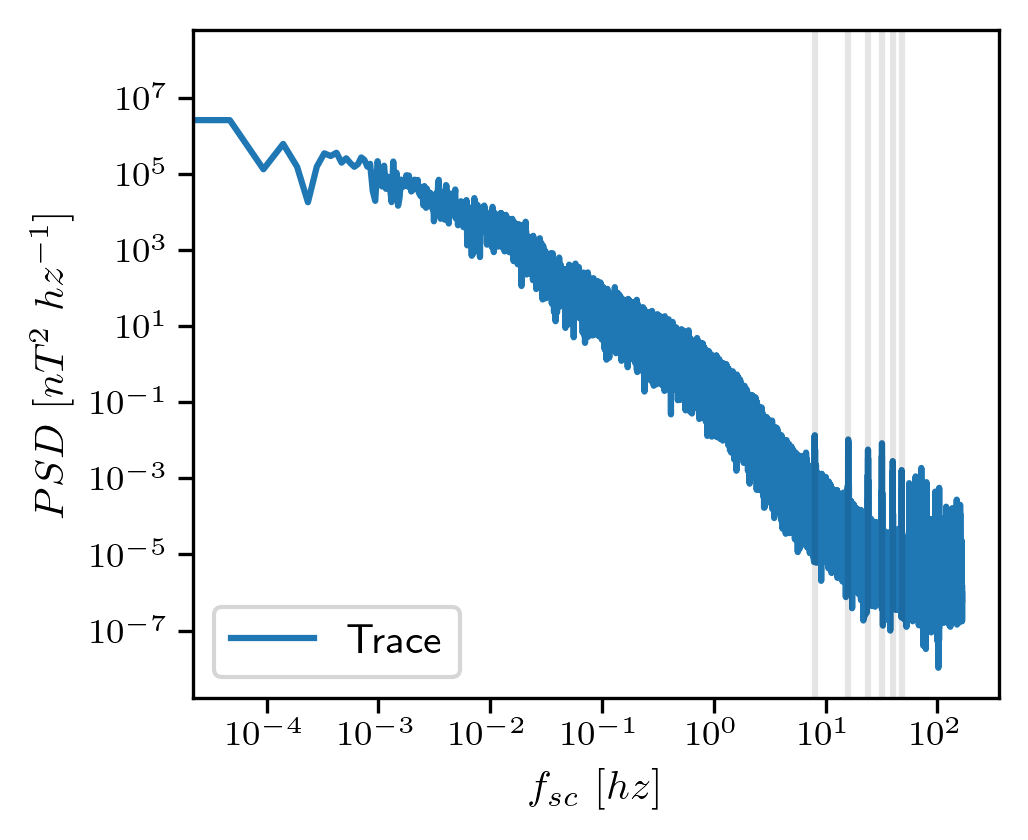

In [28]:
fig, ax =figs.initializeFigure(r'$PSD ~[nT^{2}~ hz^{-1}]$', r'$f_{sc} ~[hz]$')


plt.loglog(fin['Mag']['f_B_orig'], fin['Mag']['PSD_f_orig'], label ='Trace')
# plt.loglog(fin['Mag']['f_B_orig'], fin['Mag']['PSD_f_orig_R'], label ='R comp')
# plt.loglog(fin['Mag']['f_B_orig'], fin['Mag']['PSD_f_orig_T'], label ='T comp')
# plt.loglog(fin['Mag']['f_B_orig'], fin['Mag']['PSD_f_orig_N'], label ='N comp')
plt.axvline(x=8, c='k', alpha=0.1)

plt.axvline(x=16, c='k', alpha=0.1)
plt.axvline(x=24, c='k', alpha=0.1)
plt.axvline(x=32, c='k', alpha=0.1)
plt.axvline(x=40, c='k', alpha=0.1)
plt.axvline(x=48, c='k', alpha=0.1)
plt.legend()

Selected segment: 2024-10-10 00:04:12 -> 2024-10-10 05:59:48.999000 | N = 7112334
Estimated fs = 333.333333 Hz
Notches applied at (Hz): [8.0, 16.0, 24.0, 32.0, 40.0, 48.0, 56.0, 64.0, 72.0, 80.0] ...


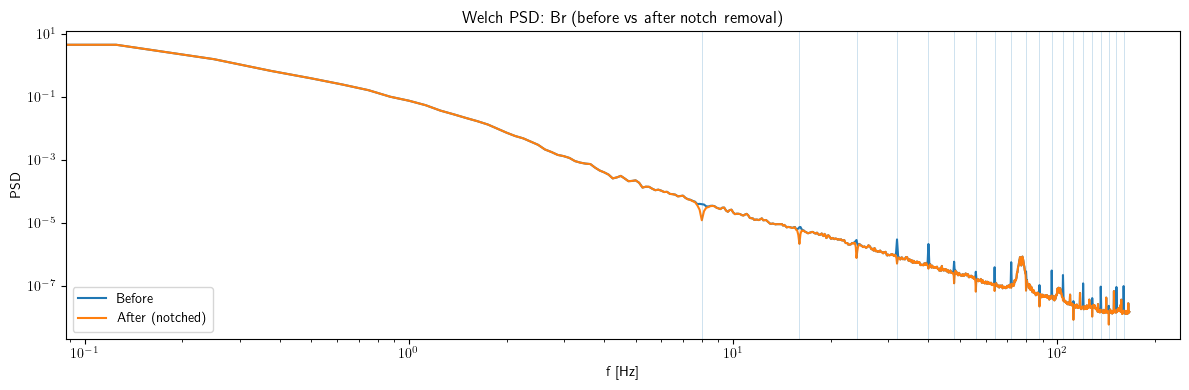

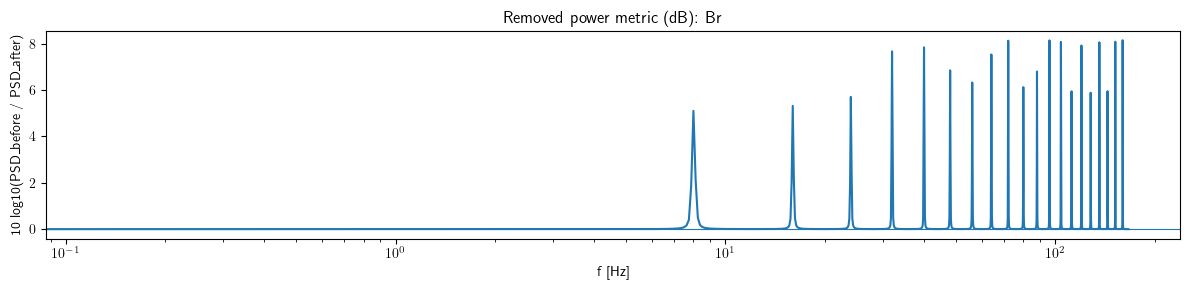

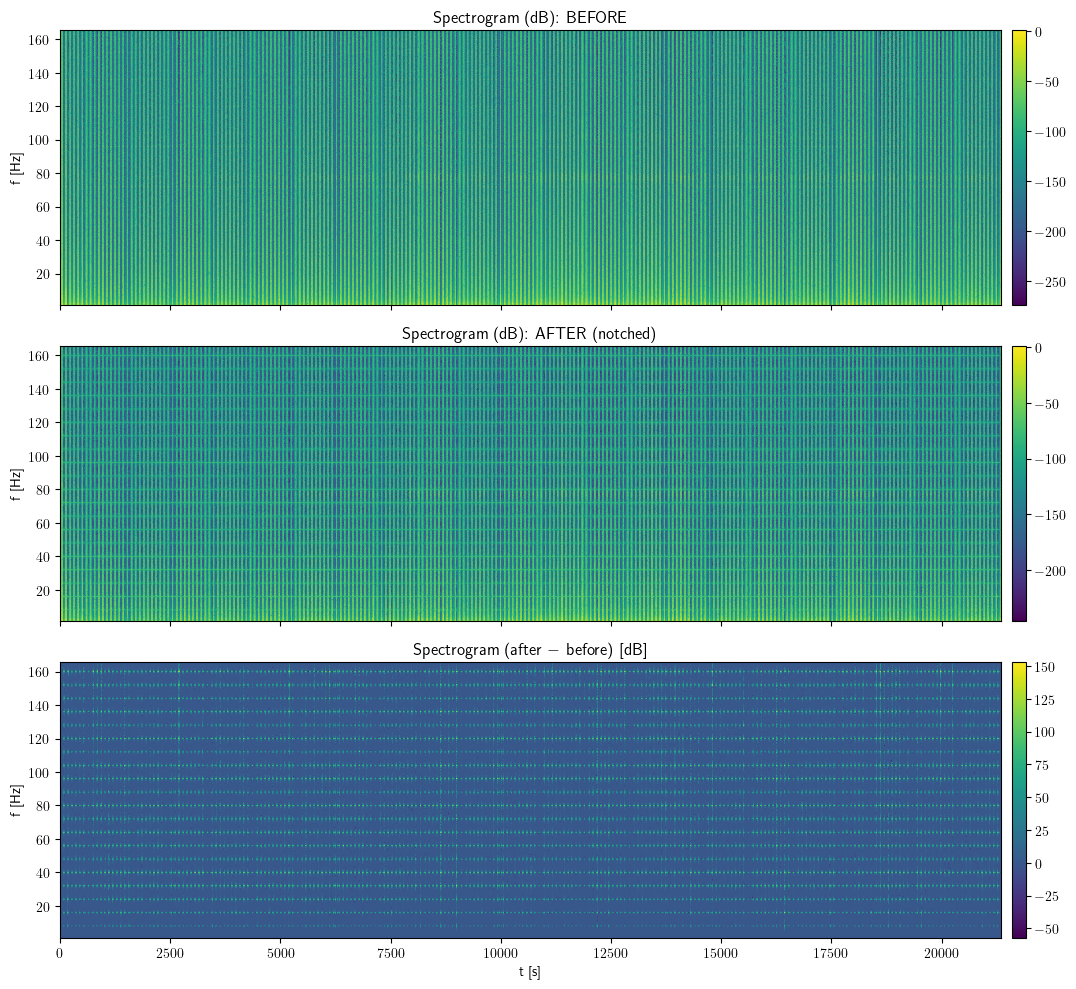

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, stft, iirnotch, tf2sos, sosfiltfilt

# ----------------------------
# Helpers
# ----------------------------
def _interp_nans_1d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, float)
    n = x.size
    if n == 0:
        return x
    ok = np.isfinite(x)
    if ok.all():
        return x
    if ok.sum() < 2:
        return np.zeros_like(x)
    idx = np.arange(n)
    y = x.copy()
    y[~ok] = np.interp(idx[~ok], idx[ok], x[ok])
    return y

def notch_remove_harmonics(
    x: np.ndarray,
    fs: float,
    *,
    base_hz: float = 8.0,
    fmax: float | None = None,
    half_width_hz: float = 0.6,
    extra_freqs: tuple[float, ...] = (),
    order_repeat: int = 1,
) -> tuple[np.ndarray, list[float]]:
    """
    Narrow notch removal at k*base_hz (and optional extra_freqs).
    Returns (filtered_x, notch_centers_hz).
    """
    x = np.asarray(x, float)
    fs = float(fs)
    nyq = 0.5 * fs

    if fmax is None or (not np.isfinite(fmax)):
        fmax = nyq - 1e-6
    fmax = float(min(fmax, nyq - 1e-6))

    freqs = []
    if np.isfinite(base_hz) and base_hz > 0:
        kmax = int(np.floor(fmax / base_hz))
        freqs.extend([k * base_hz for k in range(1, kmax + 1)])
    freqs.extend([float(ff) for ff in extra_freqs if np.isfinite(ff)])

    freqs = sorted({ff for ff in freqs if (ff > 0) and (ff < nyq)})
    if len(freqs) == 0:
        return x.copy(), freqs

    half_width_hz = float(max(half_width_hz, 1e-6))

    def _filter_1d(sig: np.ndarray) -> np.ndarray:
        y = _interp_nans_1d(sig)
        for _ in range(int(max(1, order_repeat))):
            for f0 in freqs:
                Q = float(max(5.0, f0 / (2.0 * half_width_hz)))
                b, a = iirnotch(w0=f0, Q=Q, fs=fs)
                sos = tf2sos(b, a)
                y = sosfiltfilt(sos, y)
        return y

    if x.ndim == 1:
        return _filter_1d(x), freqs

    if x.ndim == 2 and x.shape[1] in (2, 3):
        out = np.empty_like(x)
        for j in range(x.shape[1]):
            out[:, j] = _filter_1d(x[:, j])
        return out, freqs

    return _filter_1d(x.ravel()), freqs


# ============================================================
# 1) Select your interval from merged SOLO dataset
# ============================================================
Bdf = fin["Mag"]["B_resampled"]

t_start = Bdf.index[0]
t_stop  = t_start + pd.Timedelta(seconds=60000)

Bseg = Bdf.loc[t_start:t_stop, ["Br","Bt","Bn"]].copy()
print("Selected segment:", Bseg.index[0], "->", Bseg.index[-1], "| N =", len(Bseg))

# ============================================================
# 2) Infer sampling rate from index
# ============================================================
t_ns = Bseg.index.view("int64")
dt = np.diff(t_ns).astype(np.float64) * 1e-9
fs = 1.0 / np.nanmedian(dt)
print(f"Estimated fs = {fs:.6f} Hz")

B = Bseg.to_numpy(float)

# ============================================================
# 3) Apply notch removal at 8 Hz harmonics (optionally add 1.33 Hz family)
# ============================================================
# If you want to also notch 1.33 Hz harmonics, uncomment:
# extra = tuple(1.33 * k for k in range(1, 1+int((0.5*fs)/1.33)))
extra = ()

Bout, notch_centers = notch_remove_harmonics(
    B, fs,
    base_hz=8.0,
    fmax=min(0.5*fs - 1.0, 180.0),
    half_width_hz=0.05,
    extra_freqs=extra,
    order_repeat=1,
)

print("Notches applied at (Hz):", notch_centers[:10], "..." if len(notch_centers) > 10 else "")
Bclean = pd.DataFrame(Bout, index=Bseg.index, columns=["Br","Bt","Bn"])

# ============================================================
# 4) PSD before/after (Welch) for Br
# ============================================================
nper_psd = int(round(8.0 * fs))
nper_psd = max(256, min(nper_psd, len(Bseg)))
nover_psd = int(round(0.5 * nper_psd))

f_psd, P_before = welch(
    Bseg["Br"].to_numpy(float),
    fs=fs,
    window="hann",
    nperseg=nper_psd,
    noverlap=nover_psd,
    detrend="constant",
    scaling="density",
)
_, P_after = welch(
    Bclean["Br"].to_numpy(float),
    fs=fs,
    window="hann",
    nperseg=nper_psd,
    noverlap=nover_psd,
    detrend="constant",
    scaling="density",
)

plt.figure(figsize=(12,4))
plt.loglog(f_psd, P_before, label="Before")
plt.loglog(f_psd, P_after,  label="After (notched)")
plt.xlabel("f [Hz]")
plt.ylabel("PSD")
plt.title("Welch PSD: Br (before vs after notch removal)")
for k in range(1, 1+int(np.floor(min(180.0, 0.5*fs-1.0)/8.0))):
    plt.axvline(8.0*k, lw=0.6, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,3))
plt.semilogx(f_psd, 10*np.log10((P_before+1e-30)/(P_after+1e-30)))
plt.axhline(0, lw=0.8)
plt.xlabel("f [Hz]")
plt.ylabel(r"10 log10(PSD_before / PSD_after)")
plt.title("Removed power metric (dB): Br")
plt.tight_layout()
plt.show()

# ============================================================
# 5) Spectrogram before/after (STFT dB) for Br + Δ
# ============================================================
nper_tf = int(round(8.0 * fs))
nper_tf = max(256, min(nper_tf, len(Bseg)))
nover_tf = int(round(0.75 * nper_tf))

f_sp, tt_sp, Zb = stft(
    Bseg["Br"].to_numpy(float),
    fs=fs,
    window="hann",
    nperseg=nper_tf,
    noverlap=nover_tf,
    boundary="zeros",
    padded=True,
)
_, _, Za = stft(
    Bclean["Br"].to_numpy(float),
    fs=fs,
    window="hann",
    nperseg=nper_tf,
    noverlap=nover_tf,
    boundary="zeros",
    padded=True,
)

Sb_db = 10.0*np.log10(np.maximum(np.abs(Zb)**2, 1e-30))
Sa_db = 10.0*np.log10(np.maximum(np.abs(Za)**2, 1e-30))
Sd_db = Sa_db - Sb_db

fmax_plot = min(180.0, 0.5*fs - 1.0)
keep = (f_sp >= 1.0) & (f_sp <= fmax_plot)

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

im0 = axs[0].pcolormesh(tt_sp, f_sp[keep], Sb_db[keep,:], shading="auto")
axs[0].set_ylabel("f [Hz]")
axs[0].set_title("Spectrogram (dB): BEFORE")
fig.colorbar(im0, ax=axs[0], pad=0.01)

im1 = axs[1].pcolormesh(tt_sp, f_sp[keep], Sa_db[keep,:], shading="auto")
axs[1].set_ylabel("f [Hz]")
axs[1].set_title("Spectrogram (dB): AFTER (notched)")
fig.colorbar(im1, ax=axs[1], pad=0.01)

im2 = axs[2].pcolormesh(tt_sp, f_sp[keep], Sd_db[keep,:], shading="auto")
axs[2].set_ylabel("f [Hz]")
axs[2].set_xlabel("t [s]")
axs[2].set_title(" Spectrogram (after − before) [dB]")
fig.colorbar(im2, ax=axs[2], pad=0.01)

plt.tight_layout()
plt.show()


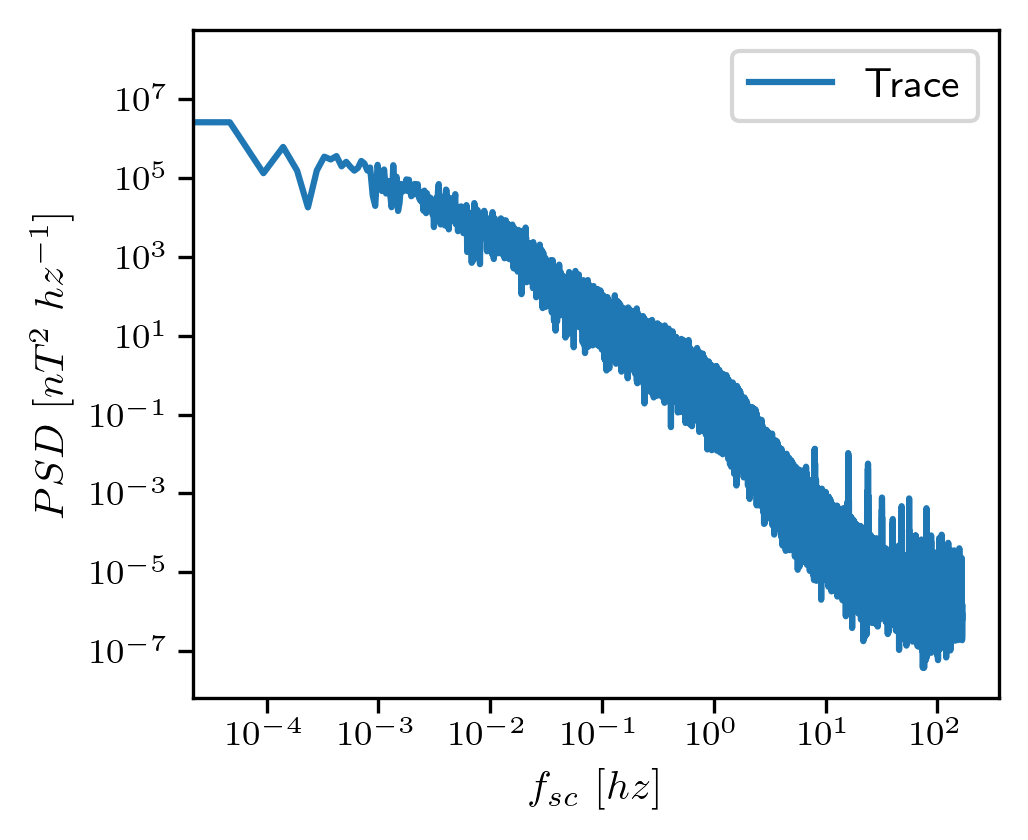

In [42]:
fig, ax =figs.initializeFigure(r'$PSD ~[nT^{2}~ hz^{-1}]$', r'$f_{sc} ~[hz]$')


plt.loglog(fin['Mag']['f_B_orig'], fin['Mag']['PSD_f_orig'], label ='Trace')
# plt.loglog(fin['Mag']['f_B_orig'], fin['Mag']['PSD_f_orig_R'], label ='R comp')
# plt.loglog(fin['Mag']['f_B_orig'], fin['Mag']['PSD_f_orig_T'], label ='T comp')
# plt.loglog(fin['Mag']['f_B_orig'], fin['Mag']['PSD_f_orig_N'], label ='N comp')

plt.legend()

DEBUG: {'method': 'acds', 'status': 'ok', 'fs': 300.0, 'n': 54000, 'nchan': 3, 'n_harmonics': 18, 'harmonics': (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18), 'freq_min': 6.0, 'line_base_hz': 8.0, 'line_max_hz': 149.5, 'track_enable': True, 'track_channel': 0, 'track_kref': 1, 'track_f0_min': 7.3, 'track_f0_max': 8.7, 'track_smooth_win': 601, 'env_bw_hz': 1.2, 'env_order': 3, 'env_zero_phase': False, 'gate_enable': True, 'gate_db': 6.0, 'gate_smooth_seconds': 1.0, 'chunk_seconds': 900.0, 'df_hz': None, 'nperseg': None, 'noverlap': None, 'subtracted_samples': 0, 'gated_samples': 0}


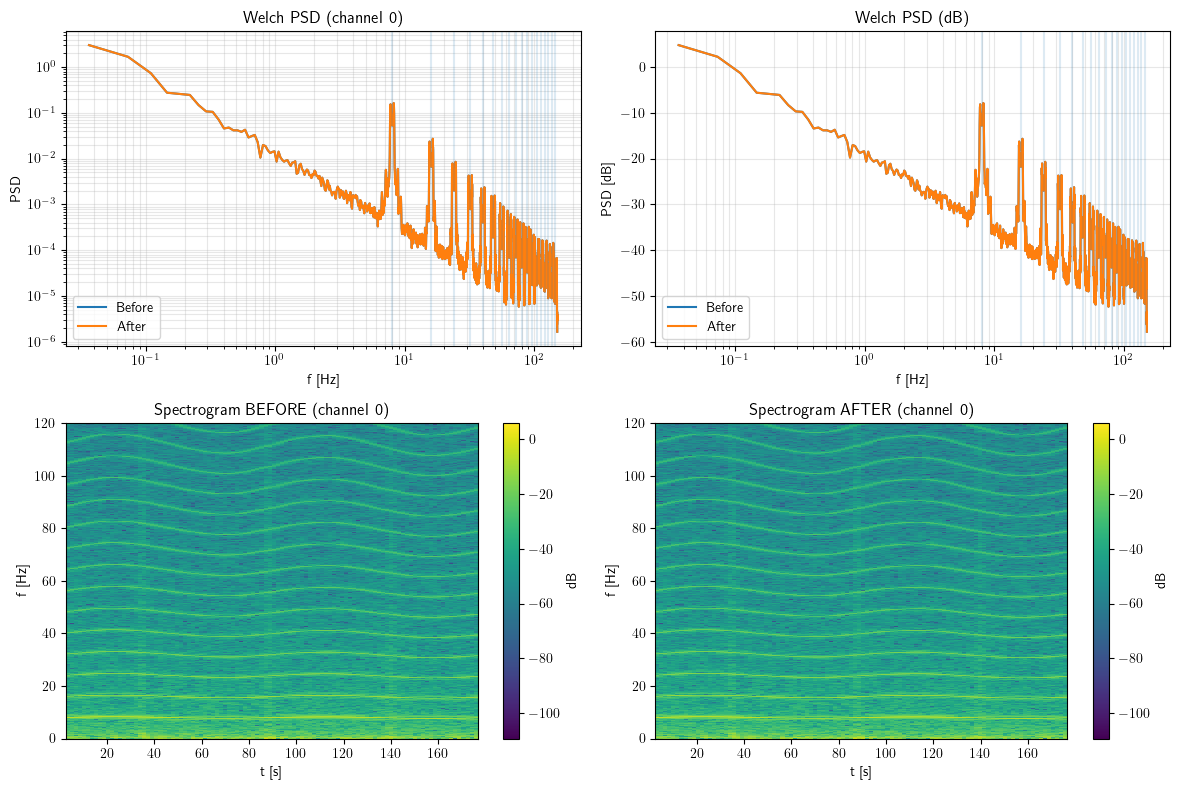

In [22]:
# wheel_noise_removal.py
# -*- coding: utf-8 -*-
"""
Fast, bias-safe wheel/clock comb removal for SolO/SCM-like magnetic time series.

===============================================================================
WHY YOUR STFT INPAINTING IS FAILING + SLOW (IN ONE PARAGRAPH, NO HANDWAVING)
===============================================================================

Your STFT method is structurally vulnerable because it tries to decide, TF-bin-by-TF-bin,
which energy is “artifact” and then replaces those bins. That is (i) statistically biased
unless the baseline estimator is an unbiased estimator of *mean* TF power, and (ii) extremely
sensitive to leakage/drift/sidebands which spread energy across bins in a time-dependent way.
On top of that, your implementation is slow because it loops over (harmonics × time bins × channels)
and repeatedly constructs index sets; that produces O(H·T) Python overhead on multi-hour data.

===============================================================================
NEW APPROACH (FROM THE GROUND UP): ADAPTIVE COMPLEX DEMODULATION SUBTRACTION (ACDS)
===============================================================================

Model (additive artifact):
    x(t) = x_phys(t) + sum_k Re{ c_k(t) exp(i θ_k(t)) }

Key design choice:
  - We do NOT attenuate magnitudes and do NOT "clip power". Those operations create PSD notches
    because they reduce E[|noise|^2] at specific frequencies.
  - Instead, we estimate the *coherent narrowband component* via complex demodulation and subtract it.
    If the artifact is a slowly-varying sinusoid (amplitude/phase drift), subtraction removes only that
    coherent part while leaving the stochastic broadband background unbiased in expectation.

Algorithm summary:
  1) Track a drifting base frequency f0(t) (near ~8 Hz) using a narrowband bandpass + analytic phase
     instantaneous frequency estimator. (This is O(N) and fast.)
  2) Build base phase θ0(t) = 2π ∫ f0(t) dt.
  3) For each harmonic k:
       u_k(t) = x(t) exp(-i k θ0(t))              (demodulate to baseband)
       c_k(t) = LPF(u_k(t))                       (extract slow complex envelope)
       x_hat_k(t) = 2 Re{ c_k(t) exp(i k θ0(t)) }  (reconstruct artifact harmonic)
       x(t) <- x(t) - gate_k(t) * x_hat_k(t)       (subtract, with optional robust gating)

Why this preserves the broadband PSD (the important part):
  - For broadband turbulence noise n(t), u_k(t)=n(t)e^{-ikθ0(t)} is still zero-mean.
    After LPF, E[c_k(t)]≈0, so E[x_hat_k(t)]≈0: no systematic shrinkage of broadband power.
  - The artifact component is *coherent* at the tracked phase; it survives LPF and is removed.

Speed:
  - No STFT, no spectrogram loops. Main cost is (H harmonics) × (one IIR lowpass) on an (N×C) array.
  - Uses scipy.signal.sosfilt with streaming filter states -> fast and chunkable.

Dependencies: numpy + scipy only (matplotlib only in __main__ test).

"""

from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Any, Dict, Optional, Sequence, Tuple, Union, List

import numpy as np
from scipy.signal import butter, sosfilt, sosfiltfilt, sosfilt_zi, hilbert, welch, spectrogram, medfilt


_EPS = 1e-30


# =============================================================================
# Utilities
# =============================================================================

def _interp_nans_1d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    n = x.size
    if n == 0:
        return x
    ok = np.isfinite(x)
    if ok.all():
        return x
    if ok.sum() < 2:
        return np.zeros_like(x)
    idx = np.arange(n, dtype=float)
    y = x.copy()
    y[~ok] = np.interp(idx[~ok], idx[ok], x[ok])
    return y


def _as_2d_channels(x: np.ndarray) -> Tuple[np.ndarray, int]:
    x = np.asarray(x, dtype=float)
    if x.ndim == 1:
        return _interp_nans_1d(x)[:, None], 1
    if x.ndim == 2 and x.shape[1] in (2, 3) and x.shape[0] > 0:
        cols = [_interp_nans_1d(x[:, j]) for j in range(x.shape[1])]
        return np.stack(cols, axis=1), x.shape[1]
    xf = _interp_nans_1d(x.ravel())
    return xf[:, None], 1


def _odd_int(x: int) -> int:
    x = int(x)
    if x < 1:
        x = 1
    if x % 2 == 0:
        x += 1
    return x


def _median_smooth_1d(y: np.ndarray, win: int) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    win = _odd_int(win)
    if y.size < win or win < 3:
        return y
    return medfilt(y, kernel_size=win)


def _clip_finite(x: np.ndarray, lo: float, hi: float) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, np.nan)
    x = np.clip(x, lo, hi)
    return x


def _fill_nan_by_interp(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    n = y.size
    if n == 0:
        return y
    ok = np.isfinite(y)
    if ok.all():
        return y
    if ok.sum() < 2:
        return np.nan_to_num(y, nan=0.0)
    idx = np.arange(n, dtype=float)
    out = y.copy()
    out[~ok] = np.interp(idx[~ok], idx[ok], out[ok])
    return out


@dataclass
class _TrackInfo:
    channel: int
    kref: int
    f0_nom: float
    f0_min: float
    f0_max: float
    smooth_win: int
    amp_quantile: float


# =============================================================================
# Base frequency tracking: narrowband analytic instantaneous frequency
# =============================================================================

def _track_base_frequency(
    x: np.ndarray,
    fs: float,
    *,
    f0_nom: float,
    drift_max_hz: float,
    track_harmonics: Sequence[int],
    track_half_width_hz: float,
    smooth_seconds: float,
    amp_quantile: float,
    use_zero_phase: bool,
) -> Tuple[np.ndarray, _TrackInfo]:
    """
    Track f0(t) near ~f0_nom using one "reference harmonic" kref that has the strongest line.

    Strategy:
      - Choose (channel, kref) that maximizes RMS after bandpass around kref*f0_nom.
      - Bandpass, compute analytic signal via Hilbert, estimate instantaneous freq,
        smooth and clip, convert back to base frequency.

    Returns:
      f0(t) shape (N,), TrackInfo
    """
    x = np.asarray(x, dtype=float)
    n, nchan = x.shape
    fs = float(fs)
    nyq = 0.5 * fs

    # Select best (channel, kref) by bandpassed RMS
    best_score = -np.inf
    best_j = 0
    best_k = int(track_harmonics[0]) if len(track_harmonics) else 1
    best_y = None

    for j in range(nchan):
        sig = x[:, j]
        for k in track_harmonics:
            k = int(k)
            if k < 1:
                continue
            fc = float(k) * float(f0_nom)
            lo = max(0.2, fc - float(track_half_width_hz) - float(k) * float(drift_max_hz))
            hi = min(nyq - 0.2, fc + float(track_half_width_hz) + float(k) * float(drift_max_hz))
            if not (np.isfinite(lo) and np.isfinite(hi) and hi > lo):
                continue
            if hi >= nyq:
                continue

            sos = butter(
                N=4,
                Wn=[lo, hi],
                btype="bandpass",
                fs=fs,
                output="sos",
            )

            if use_zero_phase:
                y = sosfiltfilt(sos, sig)
            else:
                y = sosfilt(sos, sig)

            score = float(np.sqrt(np.mean(y * y)))
            if score > best_score:
                best_score = score
                best_j = j
                best_k = k
                best_y = y

    if best_y is None:
        # Fallback: constant base frequency
        f0 = np.full(n, float(f0_nom), dtype=float)
        info = _TrackInfo(
            channel=0,
            kref=1,
            f0_nom=float(f0_nom),
            f0_min=float(f0_nom - drift_max_hz),
            f0_max=float(f0_nom + drift_max_hz),
            smooth_win=_odd_int(int(round(smooth_seconds * fs))),
            amp_quantile=float(amp_quantile),
        )
        return f0, info

    # Analytic signal + instantaneous frequency at kref*f0(t)
    z = hilbert(best_y)
    phase = np.unwrap(np.angle(z))
    dphi = np.diff(phase)
    # instantaneous harmonic frequency
    fk = (fs / (2.0 * np.pi)) * dphi
    fk = np.pad(fk, (0, 1), mode="edge")

    # Robust amplitude validity mask
    amp = np.abs(z)
    athr = float(np.quantile(amp, float(amp_quantile))) if amp.size > 0 else 0.0
    valid = amp >= max(athr, _EPS)

    # Smooth and clip fk
    smooth_win = _odd_int(int(round(float(smooth_seconds) * fs)))
    fk_s = _median_smooth_1d(fk, smooth_win)

    fk_min = float(best_k) * (float(f0_nom) - float(drift_max_hz))
    fk_max = float(best_k) * (float(f0_nom) + float(drift_max_hz))
    fk_s = _clip_finite(fk_s, fk_min, fk_max)

    # Where tracking amplitude is weak, interpolate fk to avoid junk
    fk_s = np.where(valid, fk_s, np.nan)
    fk_s = _fill_nan_by_interp(fk_s)

    # Base frequency
    f0 = fk_s / float(best_k)
    f0 = _clip_finite(f0, float(f0_nom) - float(drift_max_hz), float(f0_nom) + float(drift_max_hz))
    f0 = _fill_nan_by_interp(f0)

    info = _TrackInfo(
        channel=int(best_j),
        kref=int(best_k),
        f0_nom=float(f0_nom),
        f0_min=float(f0_nom - drift_max_hz),
        f0_max=float(f0_nom + drift_max_hz),
        smooth_win=int(smooth_win),
        amp_quantile=float(amp_quantile),
    )
    return f0, info


def _integrate_phase(f: np.ndarray, fs: float, *, phi0: float = 0.0) -> np.ndarray:
    """
    Discrete phase integration:
        phi[n] = phi[n-1] + 2π f[n]/fs
    """
    f = np.asarray(f, dtype=float)
    fs = float(fs)
    phi = np.empty_like(f, dtype=float)
    if f.size == 0:
        return phi
    phi[0] = float(phi0)
    if f.size > 1:
        dphi = (2.0 * np.pi / fs) * f[:-1]
        phi[1:] = phi[0] + np.cumsum(dphi)
    return phi


# =============================================================================
# Core removal: ACDS (adaptive complex demodulation subtraction)
# =============================================================================

def remove_wheel_noise(
    x: np.ndarray,
    fs: float,
    *,
    # -----------------------
    # Harmonic comb definition
    # -----------------------
    line_base_hz: float = 8.0,
    line_max_hz: Optional[float] = None,
    freq_min: float = 6.0,

    # -----------------------
    # Base-frequency tracking
    # -----------------------
    track_enable: bool = True,
    track_drift_max_hz: float = 0.6,               # maximum base drift |f0(t)-f0_nom|
    track_harmonics: Tuple[int, ...] = (1, 2, 3),  # try these to pick strongest reference harmonic
    track_half_width_hz: float = 0.8,              # additional band half-width around k*f0
    track_smooth_seconds: float = 2.0,             # median smoothing of instantaneous freq
    track_amp_quantile: float = 0.20,              # below this amp quantile -> treat tracking as invalid
    track_zero_phase: bool = True,                 # filtfilt for tracking bandpass

    # -----------------------
    # Envelope extraction (artifact amplitude/phase variation)
    # -----------------------
    env_bw_hz: float = 1.0,                         # lowpass bandwidth of envelope c_k(t)
    env_order: int = 3,
    env_zero_phase: bool = False,                   # streaming sosfilt if False; filtfilt if True

    # -----------------------
    # Removal gating (safety)
    # -----------------------
    gate_enable: bool = True,
    gate_db: float = 6.0,                           # subtract only when |c_k|^2 exceeds noise by this dB
    gate_smooth_seconds: float = 1.0,               # smooth gate envelope (time) via median

    # -----------------------
    # Chunking for speed/memory
    # -----------------------
    chunk_seconds: Optional[float] = 1200.0,        # None => full series; else streaming chunks
    dtype_work: str = "float32",                    # "float32" or "float64"

    # -----------------------
    # Debug
    # -----------------------
    return_debug: bool = False,
    **_ignored: Any,
) -> Union[np.ndarray, Tuple[np.ndarray, Dict[str, Any]]]:
    """
    Remove narrowband comb artifacts (≈ 8 Hz harmonics) without notching the broadband PSD.

    Returns:
      y or (y, debug_dict) if return_debug=True

    Notes:
      - This is subtraction of an estimated coherent narrowband component.
      - It does NOT do magnitude clipping or per-bin attenuation (which notch PSD).
      - It does NOT rely on STFT rank-1 coherence.

    """
    xin, nchan = _as_2d_channels(x)
    n = xin.shape[0]
    fs = float(fs)
    nyq = 0.5 * fs

    if n < 128 or (not np.isfinite(fs)) or fs <= 0:
        y = xin[:, 0] if nchan == 1 else xin
        dbg = {
            "method": "acds",
            "status": "trivial_return",
            "fs": float(fs) if np.isfinite(fs) else np.nan,
            "n": int(n),
            "nchan": int(nchan),
            "n_harmonics": 0,
            "track_enable": bool(track_enable),
        }
        return (y, dbg) if return_debug else y

    # Working dtype
    if str(dtype_work).lower() == "float32":
        xw = xin.astype(np.float32, copy=True)
    else:
        xw = xin.astype(np.float64, copy=True)

    # Decide max harmonic
    f0_nom = float(line_base_hz)
    if not (np.isfinite(f0_nom) and f0_nom > 0):
        f0_nom = 8.0

    fmax = float(line_max_hz) if (line_max_hz is not None and np.isfinite(line_max_hz)) else (nyq - 0.5)
    fmax = min(fmax, nyq - 0.5)
    if fmax <= float(freq_min):
        y = xw[:, 0] if nchan == 1 else xw
        dbg = {
            "method": "acds",
            "status": "no_harmonics_in_band",
            "fs": float(fs),
            "n": int(n),
            "nchan": int(nchan),
            "fmax": float(fmax),
        }
        return (y, dbg) if return_debug else y

    kmax = int(math.floor(fmax / f0_nom))
    kmax = max(1, kmax)

    # Build harmonic list (avoid super-low)
    harmonics: List[int] = []
    for k in range(1, kmax + 1):
        fk = k * f0_nom
        if fk >= float(freq_min) and fk < nyq:
            harmonics.append(k)

    if len(harmonics) == 0:
        y = xw[:, 0] if nchan == 1 else xw
        dbg = {
            "method": "acds",
            "status": "empty_harmonics",
            "fs": float(fs),
            "n": int(n),
            "nchan": int(nchan),
            "kmax": int(kmax),
        }
        return (y, dbg) if return_debug else y

    # Track base frequency f0(t)
    if track_enable:
        f0, track_info = _track_base_frequency(
            xw.astype(float, copy=False),
            fs,
            f0_nom=f0_nom,
            drift_max_hz=float(track_drift_max_hz),
            track_harmonics=tuple(track_harmonics),
            track_half_width_hz=float(track_half_width_hz),
            smooth_seconds=float(track_smooth_seconds),
            amp_quantile=float(track_amp_quantile),
            use_zero_phase=bool(track_zero_phase),
        )
    else:
        f0 = np.full(n, f0_nom, dtype=float)
        track_info = _TrackInfo(
            channel=0,
            kref=1,
            f0_nom=float(f0_nom),
            f0_min=float(f0_nom),
            f0_max=float(f0_nom),
            smooth_win=_odd_int(int(round(float(track_smooth_seconds) * fs))),
            amp_quantile=float(track_amp_quantile),
        )

    # Base phase
    theta0 = _integrate_phase(f0, fs, phi0=0.0)  # float64 for stability

    # Envelope lowpass filter
    env_bw = float(env_bw_hz)
    env_bw = max(env_bw, 0.05)  # do not go to ~0; keep stable
    if env_bw >= 0.45 * nyq:
        env_bw = 0.45 * nyq

    sos_lp = butter(
        N=int(max(1, env_order)),
        Wn=float(env_bw),
        btype="lowpass",
        fs=fs,
        output="sos",
    )

    # Gate parameters
    gate_lin = 10.0 ** (float(gate_db) / 10.0)
    gate_win = _odd_int(int(round(float(gate_smooth_seconds) * fs)))

    # Chunking setup
    if chunk_seconds is None or float(chunk_seconds) <= 0:
        chunk_len = n
    else:
        chunk_len = int(round(float(chunk_seconds) * fs))
        chunk_len = max(chunk_len, 2048)

    # For streaming env extraction (zero_phase=False) keep per-harmonic filter state
    if not env_zero_phase:
        zi0 = sosfilt_zi(sos_lp)  # (n_sections, 2)
        # expand to (n_sections, 2, nchan) complex
        zi_bank: Dict[int, np.ndarray] = {}
        for k in harmonics:
            zi_k = np.repeat(zi0[:, :, None], repeats=nchan, axis=2).astype(np.complex64, copy=True)
            zi_bank[int(k)] = zi_k
    else:
        zi_bank = {}

    # Main loop over chunks
    n_total_subtracted = 0
    n_total_gated = 0

    for s0 in range(0, n, chunk_len):
        s1 = min(n, s0 + chunk_len)

        Xc = xw[s0:s1, :]  # view
        th = theta0[s0:s1]  # float64 view

        # For each harmonic, subtract estimated narrowband component
        for k in harmonics:
            k = int(k)

            # carrier = exp(-i k θ0)
            carrier = np.exp((-1j * float(k)) * th).astype(np.complex64, copy=False)  # (Nc,)
            # demodulate
            U = Xc.astype(np.float32, copy=False) * carrier[:, None]  # (Nc, nchan) complex64

            # envelope extraction
            if env_zero_phase and (U.shape[0] >= 32):
                C = sosfiltfilt(sos_lp, U, axis=0).astype(np.complex64, copy=False)
            else:
                zi = zi_bank.get(k, None)
                if zi is None:
                    zi0 = sosfilt_zi(sos_lp)
                    zi = np.repeat(zi0[:, :, None], repeats=nchan, axis=2).astype(np.complex64, copy=True)
                    zi_bank[k] = zi
                C, zf = sosfilt(sos_lp, U, axis=0, zi=zi)
                zi_bank[k] = zf.astype(np.complex64, copy=False)

            # Optional gating: avoid subtracting when line is weak (robust)
            if gate_enable:
                # residual baseband (mostly noise if line is coherent)
                R = U - C
                # robust per-channel noise power estimate (median over time)
                Pn = np.median(np.abs(R) ** 2, axis=0) + _EPS  # (nchan,)
                Pc = np.abs(C) ** 2  # (Nc, nchan)

                # gate where coherent envelope dominates noise by gate_lin
                gate = Pc > (gate_lin * Pn[None, :])

                # smooth gate along time (median filter per channel)
                if gate_win >= 3 and gate.shape[0] >= gate_win:
                    gate_s = np.zeros_like(gate, dtype=bool)
                    for j in range(nchan):
                        # median filter on 0/1 is okay here
                        gj = medfilt(gate[:, j].astype(float), kernel_size=gate_win) >= 0.5
                        gate_s[:, j] = gj
                    gate = gate_s

                if not np.any(gate):
                    continue
            else:
                gate = None

            # reconstruct artifact: 2 Re{ C * exp(i k θ0) } = 2 Re{ C * conj(carrier) }
            artifact = 2.0 * np.real(C * np.conj(carrier)[:, None]).astype(Xc.dtype, copy=False)

            if gate is None:
                Xc -= artifact
                n_total_subtracted += artifact.shape[0] * artifact.shape[1]
            else:
                Xc -= artifact * gate.astype(Xc.dtype, copy=False)
                n_total_subtracted += int(np.sum(gate))
                n_total_gated += int(np.sum(gate))

        # write back (in-place view already updated)

    y2 = xw
    y = y2[:, 0] if nchan == 1 else y2

    dbg: Dict[str, Any] = {
        "method": "acds",
        "status": "ok",
        "fs": float(fs),
        "n": int(n),
        "nchan": int(nchan),
        "n_harmonics": int(len(harmonics)),
        "harmonics": tuple(harmonics),
        "freq_min": float(freq_min),
        "line_base_hz": float(f0_nom),
        "line_max_hz": float(fmax),
        "track_enable": bool(track_enable),
        "track_channel": int(track_info.channel),
        "track_kref": int(track_info.kref),
        "track_f0_min": float(track_info.f0_min),
        "track_f0_max": float(track_info.f0_max),
        "track_smooth_win": int(track_info.smooth_win),
        "env_bw_hz": float(env_bw),
        "env_order": int(env_order),
        "env_zero_phase": bool(env_zero_phase),
        "gate_enable": bool(gate_enable),
        "gate_db": float(gate_db),
        "gate_smooth_seconds": float(gate_smooth_seconds),
        "chunk_seconds": None if chunk_seconds is None else float(chunk_seconds),
        # STFT-related fields are not applicable here (kept for quick dashboards)
        "df_hz": None,
        "nperseg": None,
        "noverlap": None,
        # quick performance counters
        "subtracted_samples": int(n_total_subtracted),
        "gated_samples": int(n_total_gated),
    }

    return (y, dbg) if return_debug else y


# =============================================================================
# Self-test (synthetic turbulence + drifting comb) with PSD/spectrogram plots
# =============================================================================

if __name__ == "__main__":
    import matplotlib.pyplot as plt

    rng = np.random.default_rng(123)

    fs = 300.0
    T = 180.0
    n = int(T * fs)
    t = np.arange(n) / fs

    def colored_noise_powerlaw(alpha: float, n: int, fs: float, rng: np.random.Generator) -> np.ndarray:
        f = np.fft.rfftfreq(n, d=1.0 / fs)
        amp = np.ones_like(f)
        amp[1:] = f[1:] ** (-alpha / 2.0)
        phase = rng.uniform(0, 2 * np.pi, size=f.size)
        X = amp * (np.cos(phase) + 1j * np.sin(phase))
        x = np.fft.irfft(X, n=n)
        x = (x - np.mean(x)) / (np.std(x) + 1e-12)
        return x

    # turbulent-like broadband + intermittency
    base = colored_noise_powerlaw(alpha=5.0 / 3.0, n=n, fs=fs, rng=rng)
    env_raw = rng.standard_normal(n)
    L = int(2.0 * fs)
    if L % 2 == 0:
        L += 1
    win = np.hanning(L)
    win = win / (np.sum(win) + 1e-12)
    env = np.convolve(env_raw, win, mode="same")
    env = np.exp(0.8 * env)
    env = env / (np.mean(env) + 1e-12)

    burst = np.zeros(n, dtype=float)
    for tb in [35.0, 88.0, 140.0]:
        w = 0.8
        burst += np.exp(-0.5 * ((t - tb) / w) ** 2)
    burst = 1.0 + 1.5 * burst

    turb = base * env * burst
    turb = (turb - np.mean(turb)) / (np.std(turb) + 1e-12)

    M = np.array(
        [[1.0, 0.2, -0.1],
         [0.1, 1.0,  0.3],
         [-0.05, 0.1, 1.0]],
        dtype=float,
    )
    noise3 = np.stack(
        [
            turb,
            colored_noise_powerlaw(alpha=1.7, n=n, fs=fs, rng=rng),
            colored_noise_powerlaw(alpha=1.5, n=n, fs=fs, rng=rng),
        ],
        axis=1,
    )
    x_phys = noise3 @ M.T
    x_phys = x_phys / (np.std(x_phys, axis=0, keepdims=True) + 1e-12)

    # comb with drift + amplitude modulation
    f0 = 8.0
    nyq = 0.5 * fs
    kmax = int(np.floor((nyq - 1.0) / f0))

    rw = np.cumsum(0.002 * rng.standard_normal(n))
    rw = np.convolve(rw, np.ones(int(5 * fs)) / (5 * fs), mode="same")
    drift = 0.25 * np.sin(2 * np.pi * t / 90.0) + 0.15 * rw

    am = 1.0 + 0.35 * np.sin(2 * np.pi * 0.6 * t) + 0.15 * np.sin(2 * np.pi * 1.1 * t + 0.3)

    comb = np.zeros((n, 3), dtype=float)
    for k in range(1, kmax + 1):
        fk = k * (f0 + drift)
        phase = 2 * np.pi * np.cumsum(fk) / fs + rng.uniform(0, 2 * np.pi)
        Ak = (0.35 / k) * am
        s = Ak * np.sin(phase)
        comb[:, 0] += 1.00 * s
        comb[:, 1] += 0.75 * s + 0.15 * Ak * np.sin(phase + 0.8)
        comb[:, 2] += 0.55 * s - 0.10 * Ak * np.sin(phase + 1.6)

    x = x_phys + comb

    y, dbg = remove_wheel_noise(
        x,
        fs,
        return_debug=True,
        line_base_hz=8.0,
        track_enable=True,
        track_drift_max_hz=0.7,
        track_harmonics=(1, 2, 3),
        track_half_width_hz=0.9,
        track_smooth_seconds=2.0,
        env_bw_hz=1.2,
        env_order=3,
        env_zero_phase=False,
        gate_enable=True,
        gate_db=6.0,
        gate_smooth_seconds=1.0,
        chunk_seconds=900.0,
        dtype_work="float32",
    )

    print("DEBUG:", dbg)

    # Welch PSD and spectrogram (channel 0)
    x0 = x[:, 0]
    y0 = y[:, 0]

    fW, Px = welch(x0, fs=fs, nperseg=8192, window="hann")
    _,  Py = welch(y0, fs=fs, nperseg=8192, window="hann")

    fSx, tSx, Sx = spectrogram(x0, fs=fs, nperseg=2048, noverlap=1536, window="hann", scaling="density", mode="psd")
    fSy, tSy, Sy = spectrogram(y0, fs=fs, nperseg=2048, noverlap=1536, window="hann", scaling="density", mode="psd")

    plt.figure(figsize=(12, 8))

    ax1 = plt.subplot(2, 2, 1)
    ax1.loglog(fW[1:], Px[1:], label="Before")
    ax1.loglog(fW[1:], Py[1:], label="After")
    ax1.set_xlabel("f [Hz]")
    ax1.set_ylabel("PSD")
    ax1.set_title("Welch PSD (channel 0)")
    ax1.grid(True, which="both", alpha=0.3)
    for k in range(1, int((0.5 * fs) // f0) + 1):
        ax1.axvline(k * f0, alpha=0.15)
    ax1.legend()

    ax2 = plt.subplot(2, 2, 2)
    ax2.semilogx(fW[1:], 10 * np.log10(Px[1:] + 1e-30), label="Before")
    ax2.semilogx(fW[1:], 10 * np.log10(Py[1:] + 1e-30), label="After")
    ax2.set_xlabel("f [Hz]")
    ax2.set_ylabel("PSD [dB]")
    ax2.set_title("Welch PSD (dB)")
    ax2.grid(True, which="both", alpha=0.3)
    for k in range(1, int((0.5 * fs) // f0) + 1):
        ax2.axvline(k * f0, alpha=0.15)
    ax2.legend()

    ax3 = plt.subplot(2, 2, 3)
    im1 = ax3.pcolormesh(tSx, fSx, 10 * np.log10(Sx + 1e-30), shading="auto")
    ax3.set_ylim(0, 120)
    ax3.set_xlabel("t [s]")
    ax3.set_ylabel("f [Hz]")
    ax3.set_title("Spectrogram BEFORE (channel 0)")
    plt.colorbar(im1, ax=ax3, label="dB")

    ax4 = plt.subplot(2, 2, 4)
    im2 = ax4.pcolormesh(tSy, fSy, 10 * np.log10(Sy + 1e-30), shading="auto")
    ax4.set_ylim(0, 120)
    ax4.set_xlabel("t [s]")
    ax4.set_ylabel("f [Hz]")
    ax4.set_title("Spectrogram AFTER (channel 0)")
    plt.colorbar(im2, ax=ax4, label="dB")

    plt.tight_layout()
    plt.show()


In [19]:
import numpy as np
from scipy.signal import stft


def _time_min_run(active: np.ndarray, minlen: int) -> np.ndarray:
    if minlen <= 1:
        return active.astype(bool, copy=False)
    a = active.astype(bool, copy=False)
    n = a.size
    out = np.zeros_like(a, dtype=bool)
    i = 0
    while i < n:
        if not a[i]:
            i += 1
            continue
        j = i + 1
        while j < n and a[j]:
            j += 1
        if (j - i) >= minlen:
            out[i:j] = True
        i = j
    return out


def wheel_harmonic_tf_mask(
    x: np.ndarray,
    fs: float,
    *,
    base_hz: float = 8.0,
    fmin: float = 8.0,
    fmax: float | None = None,
    stft_seconds: float = 8.0,
    stft_overlap: float = 0.75,
    search_half_width_hz: float = 1.5,   # drift tracking
    mask_half_width_hz: float = 1.0,     # width to exclude (per harmonic)
    baseline_guard_hz: float = 0.5,
    baseline_width_hz: float = 2.0,
    baseline_q: float = 0.5,
    snr_thresh_db: float = 6.0,
    min_active_time_bins: int = 2,
    dilate_freq_bins: int = 1,           # extra leakage padding in bins
    dilate_time_bins: int = 0,
    return_debug: bool = False,
):
    """
    Build a time-frequency mask for harmonic contamination (8,16,24,... Hz),
    WITHOUT modifying the data.

    Returns:
      tf_mask: (nf, nt) bool
      f: STFT frequencies
      t: STFT times
      dbg: optional dict
    """
    x = np.asarray(x, float)
    if x.ndim == 2:
        # use first component as reference for detection
        xref = x[:, 0]
    else:
        xref = x

    n = xref.size
    if n < 256 or (not np.isfinite(fs)) or fs <= 0:
        tf_mask = np.zeros((1, 1), dtype=bool)
        if return_debug:
            return tf_mask, np.array([0.0]), np.array([0.0]), {"reason": "bad input"}
        return tf_mask, np.array([0.0]), np.array([0.0])

    fs = float(fs)
    nyq = 0.5 * fs

    if fmax is None or (not np.isfinite(fmax)):
        fmax = nyq - 1e-6
    fmax = float(min(fmax, nyq - 1e-6))

    nperseg = int(round(fs * float(stft_seconds)))
    nperseg = int(min(max(256, nperseg), n))
    noverlap = int(round(nperseg * float(stft_overlap)))
    noverlap = min(max(0, noverlap), nperseg - 1)

    f, t, Z = stft(
        xref,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        boundary="zeros",
        padded=True,
    )
    nf, nt = Z.shape
    df = float(f[1] - f[0]) if nf > 1 else np.nan

    valid_f = (f >= float(fmin)) & (f <= float(fmax))
    tf_mask = np.zeros((nf, nt), dtype=bool)

    # harmonic list
    if base_hz <= 0 or (not np.isfinite(base_hz)):
        if return_debug:
            return tf_mask, f, t, {"reason": "invalid base_hz"}
        return tf_mask, f, t

    kmax = int(np.floor(fmax / base_hz))
    harmonics = [base_hz * k for k in range(1, kmax + 1) if base_hz * k >= fmin]
    if len(harmonics) == 0:
        if return_debug:
            return tf_mask, f, t, {"reason": "no harmonics in range", "df_hz": df}
        return tf_mask, f, t

    eps = 1e-30
    snr_tracks = []

    for fc0 in harmonics:
        idx_search = np.where((np.abs(f - fc0) <= search_half_width_hz) & valid_f)[0]
        if idx_search.size < 3:
            continue

        Psearch = np.abs(Z[idx_search, :]) ** 2
        ip_local = np.argmax(Psearch, axis=0)
        ip = idx_search[ip_local]

        active = np.zeros(nt, dtype=bool)
        snr_db_t = np.full(nt, np.nan, dtype=float)

        for it in range(nt):
            ic = int(ip[it])
            fc_hat = float(f[ic])

            idx_line = np.where((np.abs(f - fc_hat) <= mask_half_width_hz) & valid_f)[0]
            if idx_line.size < 3:
                continue

            lo1 = mask_half_width_hz + baseline_guard_hz
            lo2 = lo1 + baseline_width_hz

            idx_left = np.where((f >= (fc_hat - lo2)) & (f <= (fc_hat - lo1)) & valid_f)[0]
            idx_right = np.where((f >= (fc_hat + lo1)) & (f <= (fc_hat + lo2)) & valid_f)[0]
            if idx_left.size < 3 and idx_right.size < 3:
                continue

            Pline = float(np.mean(np.abs(Z[idx_line, it]) ** 2))

            Pleft = float(np.quantile(np.abs(Z[idx_left, it]) ** 2, baseline_q)) if idx_left.size > 0 else np.nan
            Pright = float(np.quantile(np.abs(Z[idx_right, it]) ** 2, baseline_q)) if idx_right.size > 0 else np.nan

            # baseline: conservative (use max of sides if both exist)
            if np.isfinite(Pleft) and np.isfinite(Pright):
                Pbase = float(max(Pleft, Pright))
            elif np.isfinite(Pleft):
                Pbase = float(Pleft)
            elif np.isfinite(Pright):
                Pbase = float(Pright)
            else:
                continue

            if (not np.isfinite(Pbase)) or Pbase <= 0:
                continue

            snr_db = 10.0 * np.log10((Pline + eps) / (Pbase + eps))
            snr_db_t[it] = snr_db

            if snr_db >= snr_thresh_db:
                active[it] = True

        active = _time_min_run(active, int(min_active_time_bins))
        if not np.any(active):
            continue

        # build mask for active times
        for it in np.where(active)[0]:
            ic = int(ip[it])
            fc_hat = float(f[ic])
            idx_mask = np.where((np.abs(f - fc_hat) <= mask_half_width_hz) & valid_f)[0]
            if idx_mask.size > 0:
                tf_mask[idx_mask, it] = True

        snr_tracks.append(snr_db_t)

    # dilate mask in frequency/time for leakage padding
    if dilate_freq_bins > 0:
        for _ in range(int(dilate_freq_bins)):
            tf_mask = tf_mask | np.roll(tf_mask, 1, axis=0) | np.roll(tf_mask, -1, axis=0)

    if dilate_time_bins > 0:
        for _ in range(int(dilate_time_bins)):
            tf_mask = tf_mask | np.roll(tf_mask, 1, axis=1) | np.roll(tf_mask, -1, axis=1)

    dbg = {
        "fs": fs,
        "nperseg": nperseg,
        "noverlap": noverlap,
        "df_hz": df,
        "nharmonics": len(harmonics),
        "snr_thresh_db": float(snr_thresh_db),
        "mask_frac": float(np.mean(tf_mask[valid_f, :])),
        "valid_f": valid_f,
        "snr_tracks": snr_tracks,
    }

    if return_debug:
        return tf_mask, f, t, dbg
    return tf_mask, f, t


mask_frac = 0.0062211257151956 nCand = 20 thresh_db_used = 3.0


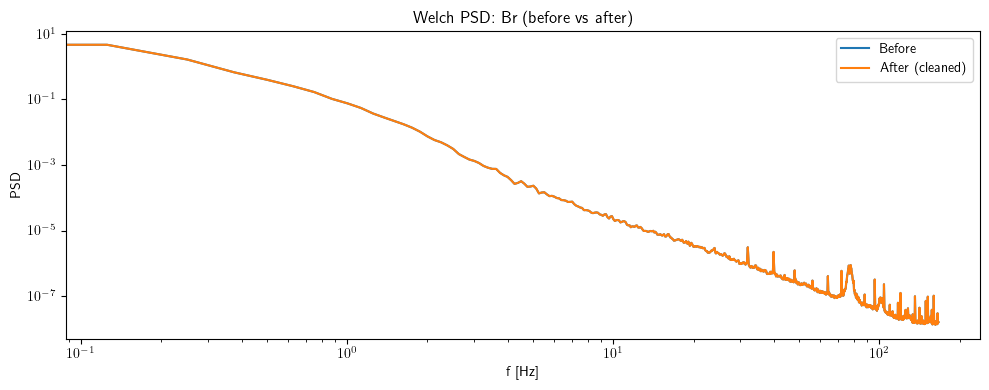

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch

Bdf = fin["Mag"]["B_resampled"]
t_start = Bdf.index[0]
t_stop  = t_start + pd.Timedelta(seconds=60000)
Bseg = Bdf.loc[t_start:t_stop, ["Br","Bt","Bn"]].copy()

t_ns = Bseg.index.view("int64")
dt = np.diff(t_ns).astype(np.float64) * 1e-9
fs = 1.0 / np.nanmedian(dt)

B = Bseg.to_numpy(float)

Bout, dbg = remove_wheel_noise(
    B, fs,
    detect_mode="harmonic_track",
    stft_seconds=8.0,
    stft_overlap=0.75,
    freq_min=8.0,
    line_base_hz=8.0,
    line_max_hz=min(180.0, 0.5*fs - 1.0),
    line_search_half_width_hz=1.25,
    remove_half_width_hz=0.75,
    baseline_guard_hz=0.35,
    baseline_width_hz=1.5,
    baseline_q=0.50,
    baseline_mode="log_interp_lr",
    coh_thresh=0.35,
    thresh_db=3.0,
    target_db_above_base=1.0,
    max_subtract_frac=0.98,
    line_shape="gaussian",
    shape_sigma_frac=0.50,
    return_debug=True,
)

print("mask_frac =", dbg["mask_frac"], "nCand =", dbg["nCand"], "thresh_db_used =", dbg["thresh_db_used"])

x_before = Bseg["Br"].to_numpy(float)
x_after  = Bout[:, 0]

nper = int(max(256, min(round(8.0*fs), len(x_before))))
nover = nper // 2

f_psd, P_before = welch(x_before, fs=fs, window="hann", nperseg=nper, noverlap=nover, scaling="density")
_,     P_after  = welch(x_after,  fs=fs, window="hann", nperseg=nper, noverlap=nover, scaling="density")

plt.figure(figsize=(10,4))
plt.loglog(f_psd, P_before, label="Before")
plt.loglog(f_psd, P_after,  label="After (cleaned)")
plt.xlabel("f [Hz]")
plt.ylabel("PSD")
plt.title("Welch PSD: Br (before vs after)")
plt.legend()
plt.tight_layout()
plt.show()
